---
## 1️⃣ Setup & Load Dependencies

In [1]:
import os
import glob
import time
import math
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw
from IPython.display import display, clear_output
import torch

print("✅ All dependencies loaded successfully!")
print(f"   PyTorch version: {torch.__version__}")
print(f"   CUDA available: {torch.cuda.is_available()}")

✅ All dependencies loaded successfully!
   PyTorch version: 2.9.1+cpu
   CUDA available: False


---
## 2️⃣ Load YOLO Detector

In [2]:
from ultralytics import YOLO

# Load YOLO model (prioritas: yolov11n.pt > yolov8n.pt > download otomatis)
if os.path.exists("yolov11n.pt"):
    detector = YOLO("yolov11n.pt")
    print("✅ Loaded: yolov11n.pt")
elif os.path.exists("yolov8n.pt"):
    detector = YOLO("yolov8n.pt")
    print("✅ Loaded: yolov8n.pt")
else:
    print("⏳ Downloading YOLO model...")
    detector = YOLO("yolov8n.pt")
    print("✅ Downloaded and loaded: yolov8n.pt")

print(f"   Model type: {detector.model.__class__.__name__}")
print(f"   Device: {detector.device}")

✅ Loaded: yolov11n.pt
   Model type: DetectionModel
   Device: cpu


---
## 3️⃣ Generate Dummy Images (Optional)

**Jalankan cell ini jika belum punya foto testing.**  
Skip jika sudah punya foto di folder `test_images/`

In [ ]:
def generate_dummy_images(output_folder='test_images/', num_images=20):
    """Generate gambar dummy dengan objek kotak (simulasi sampah) untuk testing."""
    os.makedirs(output_folder, exist_ok=True)
    
    print(f"🎨 Membuat {num_images} gambar dummy di '{output_folder}'...")
    
    for i in range(1, num_images + 1):
        # Buat gambar kosong
        img = Image.new('RGB', (640, 480), color=(50, 50, 50))
        draw = ImageDraw.Draw(img)
        
        # Gambar beberapa kotak random (simulasi sampah)
        num_boxes = random.randint(0, 3)  # 0-3 objek per gambar
        for _ in range(num_boxes):
            x1 = random.randint(50, 500)
            y1 = random.randint(50, 380)
            x2 = x1 + random.randint(40, 100)
            y2 = y1 + random.randint(40, 100)
            color = (random.randint(100, 255), random.randint(100, 255), random.randint(100, 255))
            draw.rectangle([x1, y1, x2, y2], fill=color, outline='white', width=3)
        
        # Tambah teks nomor frame
        try:
            draw.text((20, 20), f"Frame {i}", fill='white')
        except Exception:
            pass
        
        # Simpan
        img_path = os.path.join(output_folder, f'test_frame_{i:03d}.jpg')
        img.save(img_path)
    
    print(f"✅ Selesai! {num_images} gambar tersimpan di '{output_folder}'")

# JALANKAN: Generate 20 gambar dummy
generate_dummy_images(num_images=20)

---
## 4️⃣ Fungsi Utama: Deteksi → Data → Visualisasi

In [3]:
ACTION_MAP = {0: 'Utara', 1: 'Selatan', 2: 'Timur', 3: 'Barat', 4: 'Kumpulkan'}

def generate_dummy_data_from_detection(detections, img_w, img_h, episode, step, 
                                       robot_x, robot_y, battery, progress, grid_size=100):
    """Generate satu baris data dummy mirip rl_training_data.csv berdasarkan hasil deteksi."""
    best = max(detections, key=lambda d: d.get('conf', 0.0))
    xy = best.get('xyxy')
    if xy:
        x1, y1, x2, y2 = xy
        cx = (x1 + x2) / 2.0
        cy = (y1 + y2) / 2.0
        trash_x = int((cx / max(1, img_w)) * (grid_size - 1))
        trash_y = int((cy / max(1, img_h)) * (grid_size - 1))
    else:
        trash_x = random.randint(10, grid_size - 10)
        trash_y = random.randint(10, grid_size - 10)
    
    distance = math.hypot(trash_x - robot_x, trash_y - robot_y)
    
    if distance < 2.0:
        action = 4
        reward = 10.0
    else:
        dx = trash_x - robot_x
        dy = trash_y - robot_y
        if abs(dx) >= abs(dy):
            action = 2 if dx > 0 else 3
        else:
            action = 1 if dy > 0 else 0
        reward = -0.5
    
    new_robot_x = robot_x
    new_robot_y = robot_y
    if action == 0:
        new_robot_y = max(0, robot_y - 1)
    elif action == 1:
        new_robot_y = min(grid_size - 1, robot_y + 1)
    elif action == 2:
        new_robot_x = min(grid_size - 1, robot_x + 1)
    elif action == 3:
        new_robot_x = max(0, robot_x - 1)
    
    new_battery = max(0, battery - 0.5)
    done = (distance < 2.0) or (new_battery <= 0)
    
    action_text = ACTION_MAP.get(action, str(action))
    description = (f"Episode {episode} langkah {step}: Robot di ({new_robot_x},{new_robot_y}), "
                   f"baterai {new_battery:.1f}%, sampah terdekat di ({trash_x},{trash_y}) "
                   f"jarak {distance:.2f}, progress {progress:.1f}%. "
                   f"Aksi: {action_text}, reward: {reward:.2f}, selesai: {'Ya' if done else 'Tidak'}.")
    
    return {
        'episode': episode,
        'step': step,
        'robot_x': new_robot_x,
        'robot_y': new_robot_y,
        'battery': new_battery,
        'nearest_waste_x': trash_x,
        'nearest_waste_y': trash_y,
        'distance': distance,
        'progress': progress,
        'action': action,
        'reward': reward,
        'done': done,
        'description': description
    }

print("✅ Fungsi helper ready!")

✅ Fungsi helper ready!


In [4]:
def detect_and_visualize_realtime(image_folder='test_images/', detector=None, 
                                   interval=1.0, max_images=None, grid_size=100):
    """Sistem terintegrasi: deteksi → generate data → visualisasi realtime."""
    
    # Cari semua gambar
    image_paths = glob.glob(os.path.join(image_folder, '*.jpg')) + \
                  glob.glob(os.path.join(image_folder, '*.jpeg')) + \
                  glob.glob(os.path.join(image_folder, '*.png'))
    
    if not image_paths:
        print(f"❌ Tidak ada gambar di folder '{image_folder}'")
        return
    
    image_paths = sorted(image_paths)
    if max_images:
        image_paths = image_paths[:max_images]
    
    print(f"📸 Ditemukan {len(image_paths)} gambar")
    print("=" * 70)
    
    # Setup simulasi
    episode = 99
    robot_x = grid_size // 2
    robot_y = grid_size // 2
    battery = 100.0
    progress = 0.0
    
    path_x = []
    path_y = []
    all_data = []
    
    step_counter = 0
    skipped_count = 0
    
    # Setup plot
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#0D2235')
    ax.set_facecolor('#0D2235')
    
    # Loop deteksi
    for img_idx, img_path in enumerate(image_paths, start=1):
        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size
        
        # Deteksi YOLO
        detections = []
        if detector:
            try:
                results = detector(img, verbose=False)
                for res in results:
                    boxes = getattr(res, 'boxes', [])
                    for b in boxes:
                        try:
                            xy, conf, cls_id, label = None, None, None, None
                            if hasattr(b, 'xyxy'):
                                arr = b.xyxy.cpu().numpy().astype(float)
                                if arr.ndim == 2:
                                    arr = arr[0]
                                xy = [int(arr[0]), int(arr[1]), int(arr[2]), int(arr[3])]
                            if hasattr(b, 'conf'):
                                conf = float(b.conf.cpu().item())
                            if hasattr(b, 'cls'):
                                cls_id = int(b.cls.cpu().item())
                            if cls_id is not None and hasattr(res, 'names'):
                                names = res.names
                                label = names.get(cls_id) if isinstance(names, dict) else names[cls_id]
                            if conf and conf >= 0.3:
                                detections.append({'xyxy': xy, 'conf': round(conf, 3), 
                                                 'class_id': cls_id, 'label': label})
                        except Exception:
                            continue
            except Exception as e:
                print(f"⚠️ Deteksi gagal: {e}")
        
        # SKIP jika tidak ada deteksi
        if not detections:
            skipped_count += 1
            print(f"[Skip {img_idx:3d}] {os.path.basename(img_path):30s} | ❌ Tidak ada sampah - SKIP")
            continue
        
        # Ada deteksi → proses
        step_counter += 1
        
        data_row = generate_dummy_data_from_detection(
            detections, img_w, img_h, episode, step_counter, 
            robot_x, robot_y, battery, progress, grid_size
        )
        all_data.append(data_row)
        
        robot_x = data_row['robot_x']
        robot_y = data_row['robot_y']
        battery = data_row['battery']
        trash_x = data_row['nearest_waste_x']
        trash_y = data_row['nearest_waste_y']
        distance = data_row['distance']
        
        if data_row['action'] == 4 and distance < 2.0:
            progress = min(100.0, progress + 10.0)
        
        path_x.append(robot_x)
        path_y.append(robot_y)
        
        # Plot realtime
        clear_output(wait=True)
        ax.clear()
        ax.set_facecolor('#0D2235')
        ax.grid(True, color='gray', linestyle=':', alpha=0.5)
        
        ax.plot(path_x, path_y, '-', color='#4CAF50', alpha=0.6, linewidth=2, label='Robot Path')
        ax.plot(robot_x, robot_y, 'o', color='red', markersize=12, label='Robot')
        ax.text(robot_x + 1, robot_y - 2, f'({robot_x}, {robot_y})', color='red', fontsize=10, weight='bold')
        
        ax.plot(trash_x, trash_y, 'o', color='green', markersize=10, label='Sampah')
        ax.text(trash_x + 1, trash_y, f'({trash_x}, {trash_y})', color='green', fontsize=10)
        
        ax.plot([robot_x, trash_x], [robot_y, trash_y], '--', color='yellow', alpha=0.7)
        ax.text((robot_x + trash_x) / 2, (robot_y + trash_y) / 2, 
               f'Jarak: {distance:.2f}', color='yellow', fontsize=9,
               bbox=dict(facecolor='#0D2235', alpha=0.5, edgecolor='none'))
        
        ax.set_xlim(0, grid_size + 5)
        ax.set_ylim(0, grid_size + 5)
        ax.set_xlabel('X-Coordinate', color='white', fontsize=11)
        ax.set_ylabel('Y-Coordinate', color='white', fontsize=11)
        ax.set_title(f'Step {step_counter} | Episode {episode}', color='white', fontsize=12, weight='bold')
        ax.tick_params(colors='white')
        ax.legend(loc='upper right')
        
        n_det = len(detections)
        info_text = (f"📸 {os.path.basename(img_path)}\n"
                     f"🔍 Deteksi: {n_det}\n"
                     f"🤖 Robot: ({robot_x}, {robot_y})\n"
                     f"🗑️ Sampah: ({trash_x}, {trash_y})\n"
                     f"📏 Jarak: {distance:.2f}\n"
                     f"🔋 Baterai: {battery:.1f}%\n"
                     f"📊 Progress: {progress:.1f}%\n"
                     f"➡️ Aksi: {ACTION_MAP.get(data_row['action'], 'idle')}\n"
                     f"⏩ Proses: {step_counter} | Skip: {skipped_count}")
        
        fig.text(0.02, 0.02, info_text, fontsize=9, color='white',
                verticalalignment='bottom',
                bbox=dict(facecolor='#1a1a1a', alpha=0.9, boxstyle='round', 
                         edgecolor='white', linewidth=1))
        
        display(fig)
        
        print(f"[Step {step_counter:3d}] {os.path.basename(img_path):30s} | "
              f"✅ Deteksi: {n_det:2d} | Robot: ({robot_x:3d},{robot_y:3d}) | "
              f"Jarak: {distance:5.2f} | Baterai: {battery:5.1f}%")
        
        time.sleep(interval)
        
        if battery <= 0:
            print("\n⚠️ Baterai habis!")
            break
    
    plt.close()
    
    print("=" * 70)
    print(f"✅ Selesai!")
    print(f"   📊 Total gambar: {len(image_paths)}")
    print(f"   ✅ Diproses (ada sampah): {step_counter}")
    print(f"   ⏩ Di-skip (tidak ada sampah): {skipped_count}")
    
    if all_data:
        output_csv = 'realtime_detection_data.csv'
        df = pd.DataFrame(all_data)
        df.to_csv(output_csv, index=False)
        print(f"   💾 Data tersimpan: {output_csv}")
        return df
    else:
        print(f"   ⚠️ Tidak ada data untuk disimpan")
        return None

print("✅ Fungsi utama ready!")

✅ Fungsi utama ready!


---
## 5️⃣ 🚀 JALANKAN TESTING!

**Ini adalah cell utama untuk menjalankan testing.**  
Setelah menjalankan cell ini, Anda akan melihat plot animasi realtime.

c:\Users\Julman Waruwu\Documents\Kuliah semester 5\PJ GEDE\PJ_GEDE_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Julman Waruwu\Documents\Kuliah semester 5\PJ GEDE\PJ_GEDE_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Julman Waruwu\Documents\Kuliah semester 5\PJ GEDE\PJ_GEDE_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Julman Waruwu\Documents\Kuliah semester 5\PJ GEDE\PJ_GEDE_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128465 (\N{WASTEBASKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Jul

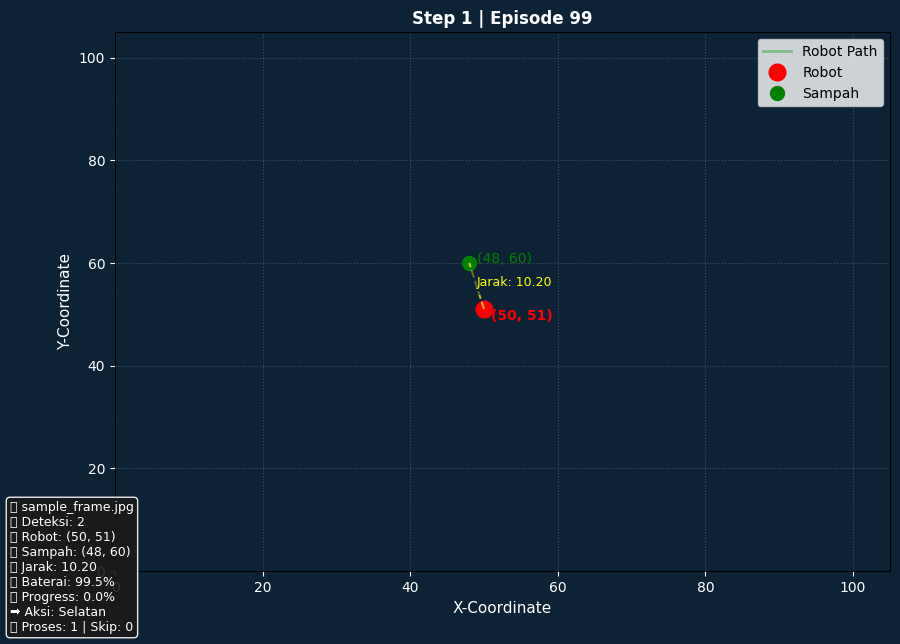

[Step   1] sample_frame.jpg               | ✅ Deteksi:  2 | Robot: ( 50, 51) | Jarak: 10.20 | Baterai:  99.5%
✅ Selesai!
   📊 Total gambar: 1
   ✅ Diproses (ada sampah): 1
   ⏩ Di-skip (tidak ada sampah): 0
   💾 Data tersimpan: realtime_detection_data.csv

📋 Preview 5 baris pertama:
✅ Selesai!
   📊 Total gambar: 1
   ✅ Diproses (ada sampah): 1
   ⏩ Di-skip (tidak ada sampah): 0
   💾 Data tersimpan: realtime_detection_data.csv

📋 Preview 5 baris pertama:


,episode,step,robot_x,robot_y,battery,nearest_waste_x,nearest_waste_y,distance,progress,action,reward,done,description
0,99,1,50,51,99.5,48,60,10.198039,0.0,1,-0.5,False,"Episode 99 langkah 1: Robot di (50,51), batera..."



📊 Total data: 1 baris


In [5]:
# TESTING UTAMA - Jalankan cell ini!

df_result = detect_and_visualize_realtime(
    image_folder='test_images/',  # Folder berisi foto
    detector=detector,             # YOLO model yang sudah di-load
    interval=1.0,                  # Jeda 1 detik per frame
    max_images=20                  # Testing 20 gambar pertama
)

# Tampilkan preview hasil
if df_result is not None:
    print("\n📋 Preview 5 baris pertama:")
    display(df_result.head())
    print(f"\n📊 Total data: {len(df_result)} baris")

---
## 6️⃣ Replay Hasil dari CSV (Optional)

Setelah testing selesai, Anda bisa replay hasil dari CSV yang tersimpan.

In [6]:
def animate_from_csv(csv_path='realtime_detection_data.csv', interval=0.5):
    """Animasi ulang dari CSV hasil testing."""
    if not os.path.exists(csv_path):
        print(f"❌ File {csv_path} tidak ditemukan")
        return
    
    df = pd.read_csv(csv_path)
    print(f"📂 Loaded: {csv_path} ({len(df)} rows)")
    
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#0D2235')
    ax.set_facecolor('#0D2235')
    
    path_x = []
    path_y = []
    
    for idx, row in df.iterrows():
        path_x.append(row['robot_x'])
        path_y.append(row['robot_y'])
        
        clear_output(wait=True)
        ax.clear()
        ax.set_facecolor('#0D2235')
        ax.grid(True, color='gray', linestyle=':', alpha=0.5)
        
        ax.plot(path_x, path_y, '-', color='#4CAF50', alpha=0.6, linewidth=2)
        ax.plot(row['robot_x'], row['robot_y'], 'o', color='red', markersize=12)
        ax.plot(row['nearest_waste_x'], row['nearest_waste_y'], 'o', color='green', markersize=10)
        
        ax.set_xlim(0, 105)
        ax.set_ylim(0, 105)
        ax.set_xlabel('X-Coordinate', color='white')
        ax.set_ylabel('Y-Coordinate', color='white')
        ax.set_title(f"Replay - Step {row['step']}", color='white', weight='bold')
        ax.tick_params(colors='white')
        
        display(fig)
        time.sleep(interval)
    
    plt.close()
    print("✅ Replay selesai!")

# JALANKAN: Replay hasil testing
# animate_from_csv('realtime_detection_data.csv', interval=0.3)

---
## 📊 Analisis Hasil Testing

In [7]:
# Analisis statistik hasil testing
if df_result is not None:
    print("📊 STATISTIK HASIL TESTING")
    print("=" * 50)
    print(f"Total steps: {len(df_result)}")
    print(f"Total reward: {df_result['reward'].sum():.2f}")
    print(f"Average distance: {df_result['distance'].mean():.2f}")
    print(f"Final battery: {df_result['battery'].iloc[-1]:.1f}%")
    print(f"Final progress: {df_result['progress'].iloc[-1]:.1f}%")
    print(f"\nAksi yang diambil:")
    for action_id, count in df_result['action'].value_counts().items():
        print(f"  {ACTION_MAP.get(action_id, action_id)}: {count} kali")
else:
    print("⚠️ Belum ada hasil testing. Jalankan cell testing terlebih dahulu.")

📊 STATISTIK HASIL TESTING
Total steps: 1
Total reward: -0.50
Average distance: 10.20
Final battery: 99.5%
Final progress: 0.0%

Aksi yang diambil:
  Selatan: 1 kali


---
## ✅ Testing Selesai!

**File yang dihasilkan:**
- `realtime_detection_data.csv` - Data hasil testing
- Plot animasi realtime di output cell

**Next Steps:**
1. Lihat file CSV untuk analisis lebih lanjut
2. Replay hasil dengan fungsi `animate_from_csv()`
3. Testing dengan lebih banyak gambar (ubah `max_images`)
4. Testing dengan foto real (upload ke `test_images/`)